Y=0, θ=0.2


Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [n]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]
Multiprocess sampling (2 chains in 2 jobs)


Y=0, θ=0.5


Metropolis: [n]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]
Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [n]


Y=5, θ=0.2


...

Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [n]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 10 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]
Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [n]


Y=10, θ=0.2


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]


Y=10, θ=0.5


Multiprocess sampling (2 chains in 2 jobs)
Metropolis: [n]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sampling: [obs]


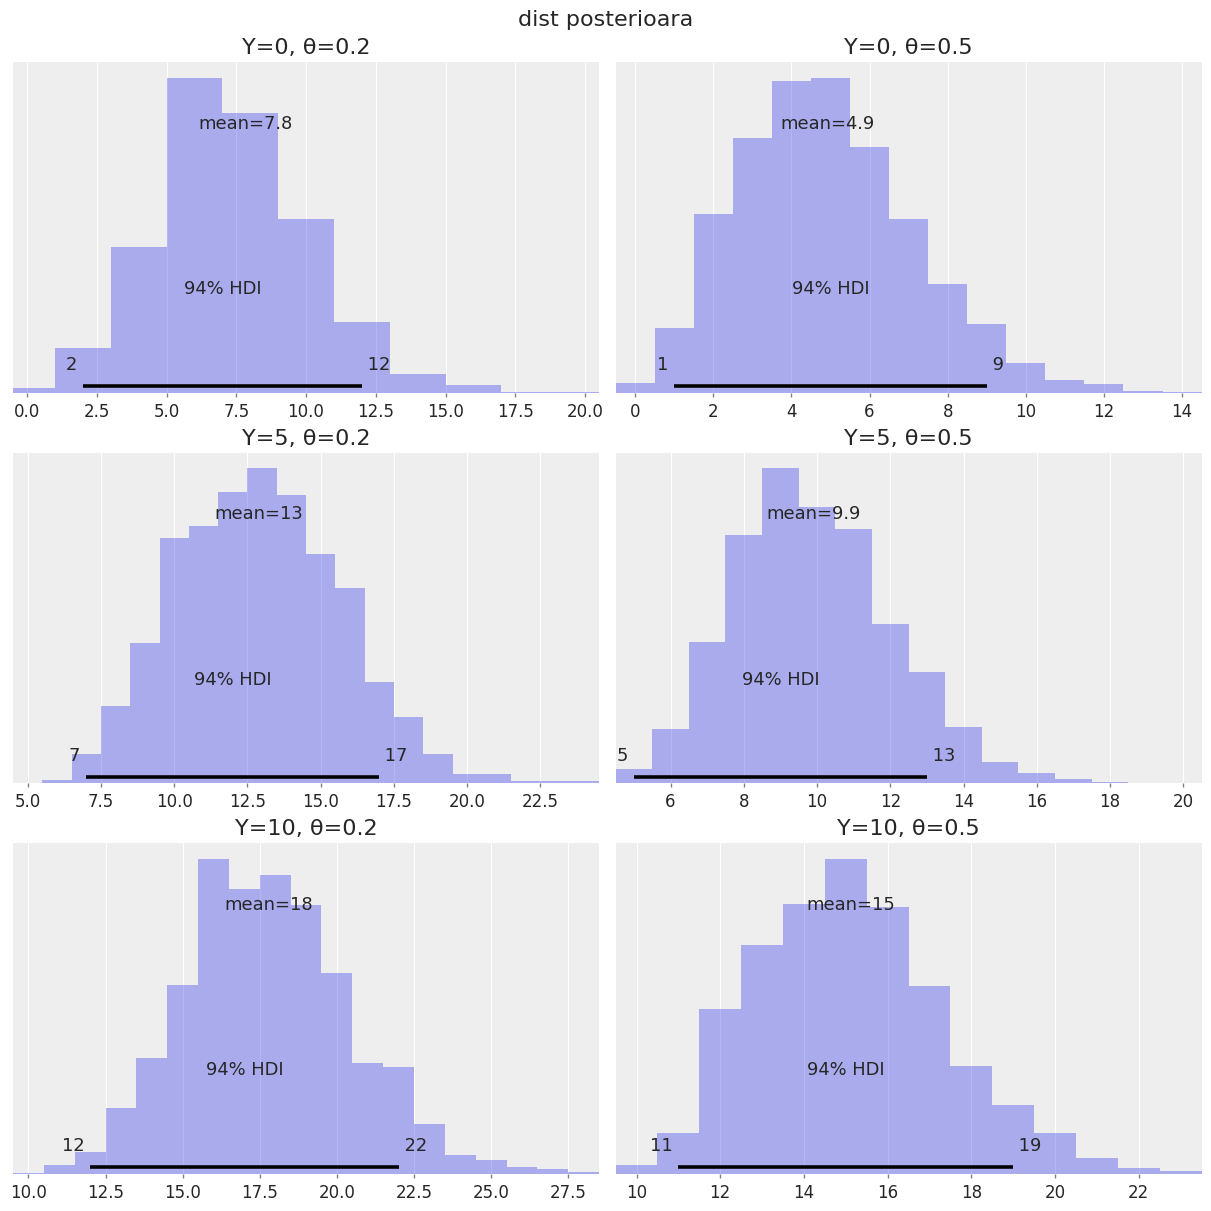

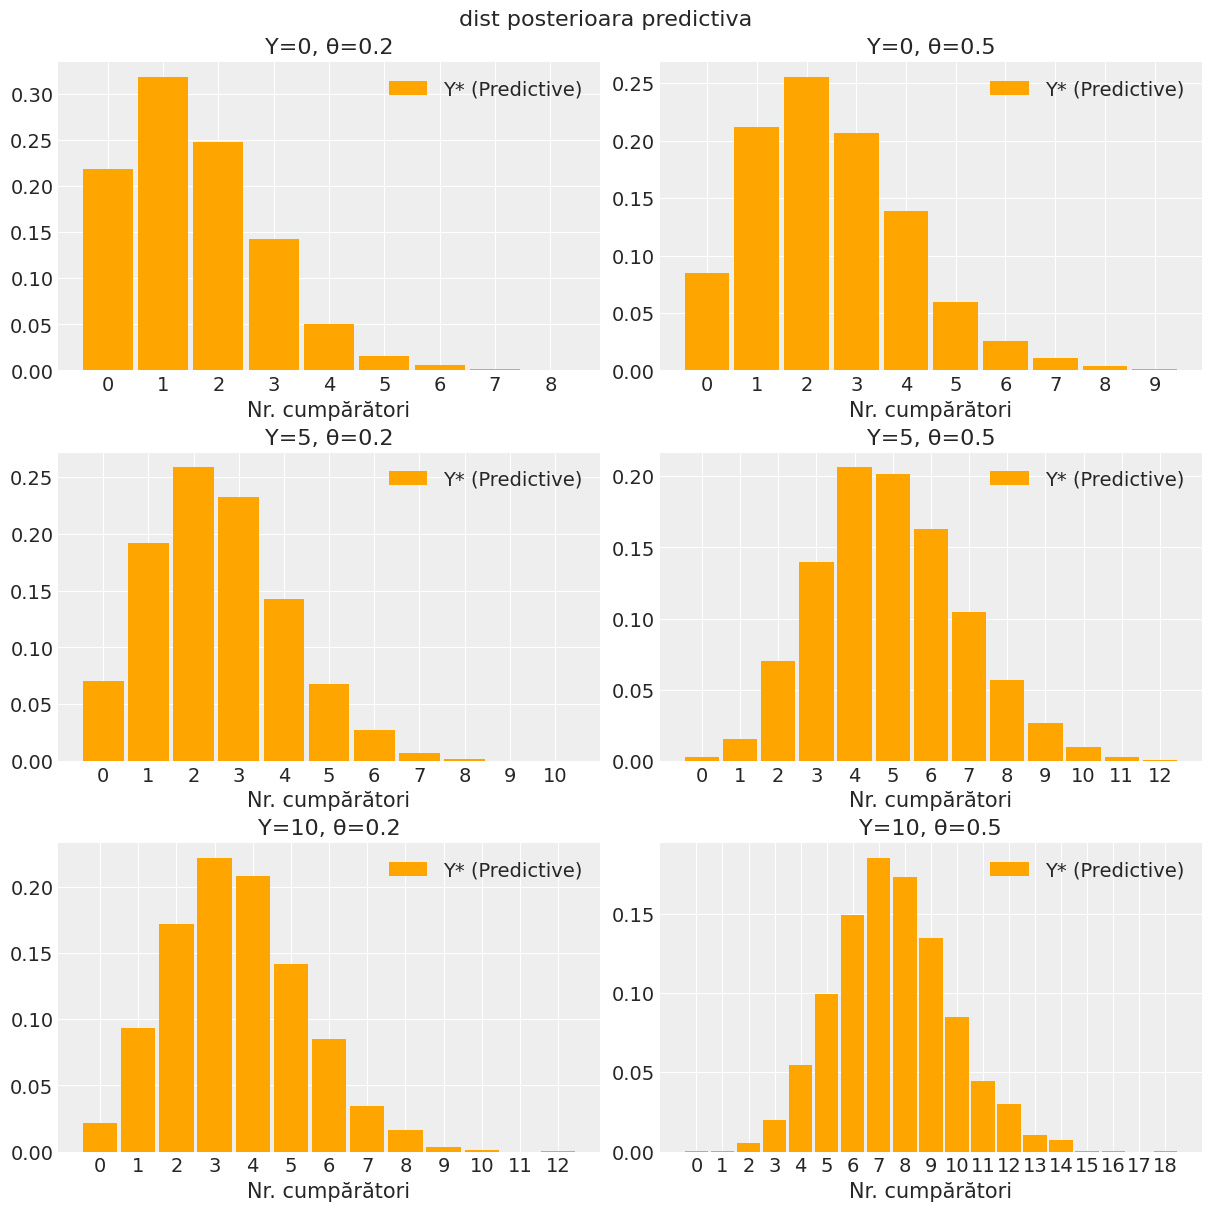

In [ ]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

az.style.use("arviz-darkgrid")

y = [0, 5, 10]
theta = [0.2, 0.5]
combinatii = [(y, t) for y in y for t in theta]

traces = {}

for Y_obs, theta in combinatii:
    key = f"Y={Y_obs}, θ={theta}"
    print(key)
    
    with pm.Model() as model:
        n = pm.Poisson("n", mu=10, initval=max(10, Y_obs + 5))
        obs = pm.Binomial("obs", n=n, p=theta, observed=Y_obs)
        trace = pm.sample(draws=2000, tune=1000, chains=2, progressbar=False)
        pp = pm.sample_posterior_predictive(trace, extend_inferencedata=True, progressbar=False)
        traces[key] = trace

fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
fig.suptitle("dist posterioara", fontsize=16)

axes = axes.flatten()
for i, (key, trace) in enumerate(traces.items()):
    az.plot_posterior(
        trace, 
        var_names=["n"], 
        ax=axes[i], 
        hdi_prob=0.94,
        textsize=12
    )
    axes[i].set_title(key)

    # b)
    # Nr total de clienti (n) nu poate fi mai mic decat nr celor care au cumparat (Y) 
    # deci distributia posterioara va avea probabilitatea zero pentru orice n<Y.
    # Daca Y are o valoare mai mare, aceasta va muta distributia posterioara catre valori
    # mai mari (daca observam multi cumparatori -> am avut mai multi vizitatori)
    # n si theta sunt invers proportionale, daca theta este mic estimam ca n a fost foarte mare
    # ca sa obtinem acelasi nr de vanzari.

fig2, axes2 = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
fig2.suptitle("dist posterioara predictiva", fontsize=16)

axes2 = axes2.flatten()
for i, (key, trace) in enumerate(traces.items()):
    az.plot_dist(
        trace.posterior_predictive["obs"],
        ax=axes2[i],
        color="orange",
        label="Y*"
    )
    axes2[i].set_title(key)
    axes2[i].legend()
    axes2[i].set_xlabel("Nr. cumparatori")

plt.show()

#d)
#distributia posterioara pt n se refera la un paramentru fix, din trecut.
#ne spune cat de siguri suntem despre valoarea nr de clienti care au intrat in magazin.
#distributia posterioara predictiva se refera la date viitoare, la ce sa ne asteptam.
